# 02. Первый бейзлайн

Нужна простая точка отсчёта. Возьмём пять признаков, которые можно посчитать к концу суток, и обычную логистическую регрессию. Сравним её с двумя совсем простыми ответами: одинаковым `score` для всех и ранжированием только по числу событий.

Проверка будет на последних трёх днях train. Test начинается позже, поэтому перемешивать даты здесь нечестно. Ноутбук рассчитан на запуск из корня проекта. Python: 3.12.10, версии библиотек записаны в `requirements.txt`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from metric import pr_curve, precision_at_recall

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 125, "font.size": 10})
BLUE, ORANGE = "#3274A1", "#E1812C"

data_dir=Path("data")
train=pd.read_csv(data_dir/"train.csv",parse_dates=["cookie_created_at","window_start_ts","window_end_ts"])
test=pd.read_csv(data_dir/"test.csv",parse_dates=["cookie_created_at","window_start_ts","window_end_ts"])
events=pd.read_csv(data_dir/"events.csv.gz",parse_dates=["event_ts"])
print(f"train: {len(train):,} кук | test: {len(test):,} кук | события: {len(events):,}")

train: 11,091 кук | test: 4,909 кук | события: 328,905


## Берём только разрешённые события

Сначала привязываем к каждому событию окно его куки. Событие на правой границе уже не подходит. Всё, что случилось позже, выбрасываем до расчёта признаков. Особенно это важно для капчи: в EDA мы увидели, что все её показы находятся за окном.

In [2]:
meta=pd.concat([train.assign(split="train"),test.assign(split="test")],ignore_index=True)
joined=events.merge(
    meta[["cookie_id","window_start_ts","window_end_ts"]],
    on="cookie_id",how="left",validate="many_to_one"
)
assert joined.window_start_ts.notna().all()
inside=joined.loc[
    joined.event_ts.ge(joined.window_start_ts) & joined.event_ts.lt(joined.window_end_ts)
].copy()
print(f"Событий внутри окон: {len(inside):,} из {len(events):,}")
print("Кук без событий внутри окна:",len(set(meta.cookie_id)-set(inside.cookie_id)))
assert not inside.event_name.eq("captcha_shown").any()

Событий внутри окон: 288,126 из 328,905


Кук без событий внутри окна: 0


## Пять признаков

Считаем события, разные объявления и поисковые запросы, медианную паузу между действиями и возраст куки на начало окна. Для куки с одним событием паузы нет, это будет пропуск. При обучении заполним его медианой, посчитанной только на обучающей части.

In [3]:
inside=inside.sort_values(["cookie_id","event_ts"],kind="mergesort")
inside["gap_sec"]=inside.groupby("cookie_id").event_ts.diff().dt.total_seconds()

per_cookie=inside.groupby("cookie_id").agg(
    events=("event_name","size"),
    items=("item_id","nunique"),
    queries=("search_query","nunique"),
    median_gap_sec=("gap_sec","median"),
)
features=meta.merge(per_cookie.reset_index(),on="cookie_id",how="left",validate="one_to_one")
for column in ["events","items","queries"]:
    features[column]=features[column].fillna(0)
features["cookie_age_days"]=(features.window_start_ts-features.cookie_created_at).dt.total_seconds()/86400

feature_cols=["events","items","queries","median_gap_sec","cookie_age_days"]
X_train=features.loc[features.split.eq("train")].reset_index(drop=True)
X_test=features.loc[features.split.eq("test")].reset_index(drop=True)
y=train.target.to_numpy()
assert X_train.cookie_id.equals(train.cookie_id) and X_test.cookie_id.equals(test.cookie_id)
assert features[feature_cols].drop(columns="median_gap_sec").notna().all().all()
print("Пропуски в медианной паузе:",X_train.median_gap_sec.isna().sum(),"в train и",X_test.median_gap_sec.isna().sum(),"в test")
display(X_train[["cookie_id"]+feature_cols].head())

Пропуски в медианной паузе: 247 в train и 104 в test


,cookie_id,events,items,queries,median_gap_sec,cookie_age_days
0,ck_54a059eb7d3ea68b,7,4,3,21.0,135.603692
1,ck_7e4de46eeab82974,41,19,5,57.5,194.576111
2,ck_9320229ef6304522,36,19,10,22.0,32.994421
3,ck_30ccd25bc1714ed9,21,10,3,54.5,0.546759
4,ck_a77c5f05948cdeef,29,16,6,51.5,94.837095


## Проверка по времени

Модель учится на 6–16 апреля, а проверяется на 17–19 апреля. На валидации 160 ботов. Эту границу сохраним и для следующих моделей, иначе сравнение будет нечестным.

In [4]:
valid=X_train.window_start_ts.ge(pd.Timestamp("2026-04-17"))
print("Обучение:",int((~valid).sum()),"кук, ботов:",int(y[~valid].sum()))
print("Валидация:",int(valid.sum()),"кук, ботов:",int(y[valid].sum()))
print("Доля ботов на валидации:",round(y[valid].mean(),4))
assert X_train.loc[~valid,"window_start_ts"].max()<X_train.loc[valid,"window_start_ts"].min()

Обучение: 9140 кук, ботов: 739
Валидация: 1951 кук, ботов: 160
Доля ботов на валидации: 0.082


## С чем сравниваемся

Константа вообще не различает кук. По официальной метрике все одинаковые `score` идут одной группой, поэтому её результат равен доле ботов на валидации. Второй ориентир смотрит только на число событий. Он не учится на метках, но уже умеет ранжировать куки.

In [5]:
y_valid=y[valid]
prior=y[~valid].mean()
constant_score=np.full(valid.sum(),prior)
count=X_train.loc[valid,"events"].to_numpy()
count_score=count/(count+1)  # число в [0, 1], порядок кук тот же

scores={"Одна оценка для всех":constant_score,"Только число событий":count_score}

## Простая обучаемая модель

Логистическая регрессия удобна как первый ориентир: быстро учится и даёт `score` от 0 до 1. Скошенные признаки берём через `log1p`, пропущенную паузу заполняем медианой и затем приводим признаки к одному масштабу. Все шаги находятся в одном `Pipeline`, поэтому параметры обработки учатся только на тренировочных строках.

In [6]:
model=Pipeline([
    ("log",FunctionTransformer(np.log1p)),
    ("fill",SimpleImputer(strategy="median",add_indicator=True)),
    ("scale",StandardScaler()),
    ("logreg",LogisticRegression(max_iter=2000,random_state=42)),
])
model.fit(X_train.loc[~valid,feature_cols],y[~valid])
model_score=model.predict_proba(X_train.loc[valid,feature_cols])[:,1]
scores["Логистическая регрессия"]=model_score

results=[]
for name,score in scores.items():
    results.append({
        "подход":name,
        "Precision при Recall ≥ 70%":precision_at_recall(y_valid,score),
        "PR-AUC":average_precision_score(y_valid,score),
    })
results=pd.DataFrame(results).set_index("подход")
display(results.round(4))

,Precision при Recall ≥ 70%,PR-AUC
подход,,
Одна оценка для всех,0.0820,0.0820
Только число событий,0.1147,0.1577
Логистическая регрессия,0.1340,0.3734


По главной метрике логистическая регрессия дала 0,134 против 0,082 у константы и 0,115 у одного счётчика событий. Это заметно лучше пустого ответа, но пока далеко от высокой точности при охвате 70% ботов. PR-AUC у модели выше, однако он здесь только дополнительная подсказка: платформа считает первую колонку.

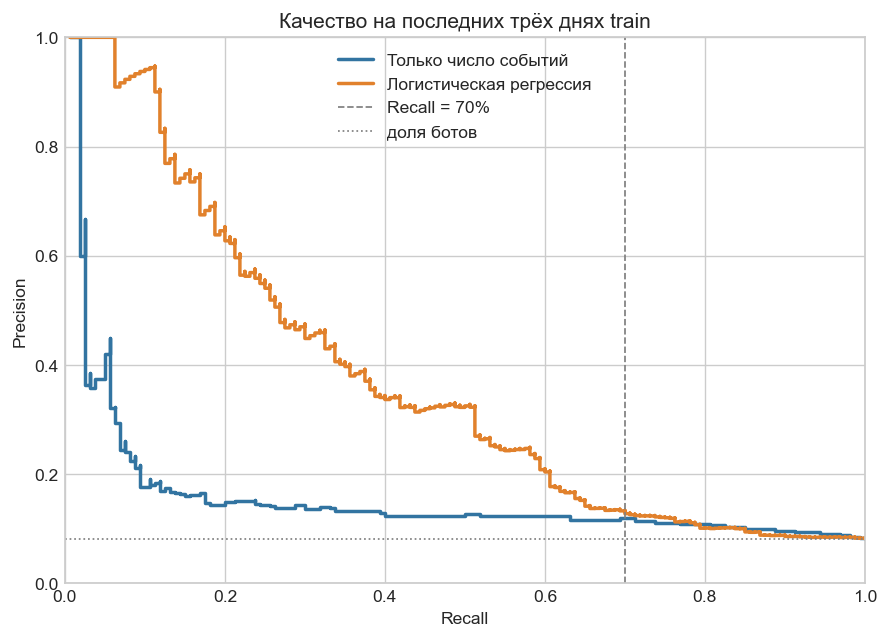

In [7]:
fig,ax=plt.subplots(figsize=(7,5),layout="constrained")
for name,color in [("Только число событий",BLUE),("Логистическая регрессия",ORANGE)]:
    precision,recall=pr_curve(y_valid,scores[name])
    ax.step(recall,precision,where="post",label=name,color=color,linewidth=2)
ax.axvline(.70,color="gray",linestyle="--",linewidth=1,label="Recall = 70%")
ax.axhline(y_valid.mean(),color="gray",linestyle=":",linewidth=1,label="доля ботов")
ax.set(xlim=(0,1),ylim=(0,1),xlabel="Recall",ylabel="Precision",title="Качество на последних трёх днях train")
ax.legend(frameon=False)
plt.show()

Кривая показывает слабое место бейзлайна: самых очевидных ботов он ранжирует неплохо, но к границе Recall = 70% precision уже сильно падает. Значит, следующим моделям нужно лучше различать ботов и активных людей в сложной части выборки.

## Первый файл с предсказаниями

Проверка закончена, теперь обучаем тот же пайплайн на всём train и считаем test. Сохраняем его отдельно как `baseline_submission.csv`: позже сравним с более сильными моделями и выберем итоговый файл.

In [8]:
model.fit(X_train[feature_cols],y)
test_score=model.predict_proba(X_test[feature_cols])[:,1]
baseline_submission=pd.DataFrame({"cookie_id":test.cookie_id,"score":test_score})

assert baseline_submission.cookie_id.is_unique
assert baseline_submission.cookie_id.equals(test.cookie_id)
assert len(baseline_submission)==len(test)
assert np.isfinite(baseline_submission.score).all()
assert baseline_submission.score.between(0,1).all()
baseline_submission.to_csv("baseline_submission.csv",index=False,float_format="%.10f")
saved=pd.read_csv("baseline_submission.csv")
assert saved.columns.tolist()==["cookie_id","score"]
assert saved.cookie_id.equals(test.cookie_id) and saved.score.between(0,1).all()
print("Сохранён baseline_submission.csv:",len(baseline_submission),"строк")
display(baseline_submission.head())

Сохранён baseline_submission.csv: 4909 строк


,cookie_id,score
0,ck_315fb710a0e371e7,0.094759
1,ck_a76ee3b3e3e522fd,0.104044
2,ck_94c9a4d382689e82,0.080402
3,ck_8eaf9509ad9462a0,0.099151
4,ck_9a88a5a989cb5bc6,0.010404


## Где бейзлайн слаб

Он видит только общую активность за сутки. В нём пока нет порядка действий, долей разных типов событий, поведения в поиске, признаков User-Agent и проверки влияния точных дублей. Один последний трёхдневный срез тоже не доказывает, что качество будет одинаковым на любых датах. Следующий этап нужен как раз для этих проверок и сравнения моделей на той же временной границе.